In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report



In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

In [ ]:
train_data = datasets.CIFAR10(root="cifar_train",
 train=True , transform=train_transform, download= True)

In [ ]:
test_data = datasets.CIFAR10(root= "cifar_test" , train=False , transform=test_transform , download=True)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

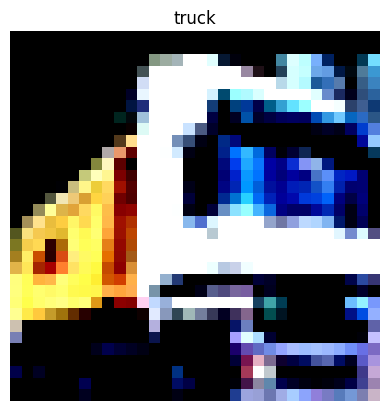

In [ ]:
image , label = train_data[1]
plt.imshow(image.permute(1,2,0))
plt.title(train_data.classes[label])
plt.axis(False)

In [ ]:
len(train_data) , len(test_data)

(50000, 10000)

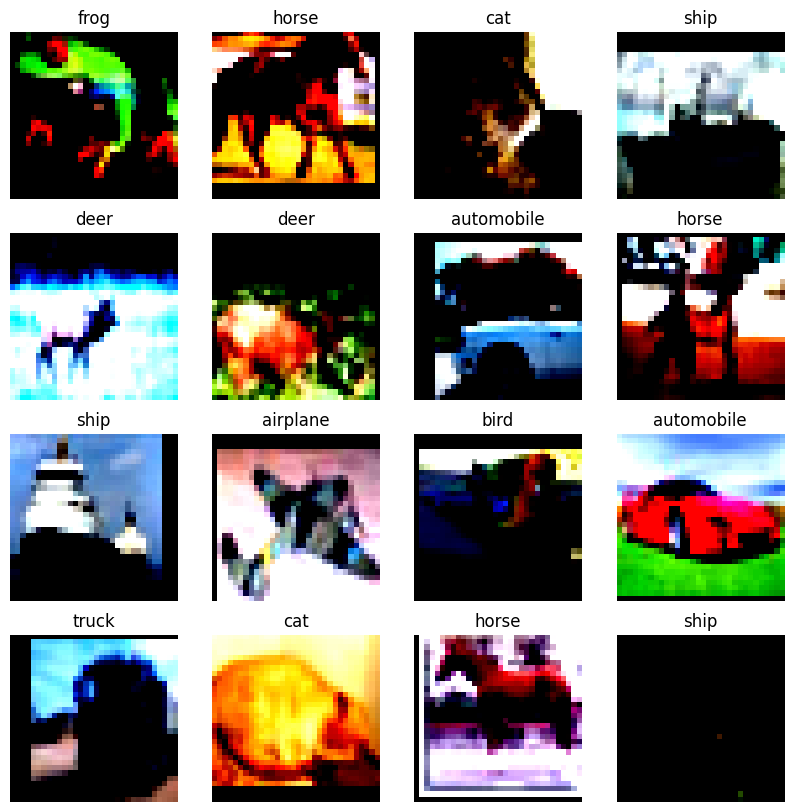

In [ ]:
# plotting the random images
torch.manual_seed(42)
fig = plt.figure(figsize = (10 ,10 ))
rows , cols = 4 ,4
for i in range(1, rows * cols +1 ):
  rand_idx = torch.randint(0 , len(train_data), size = [1]).item()
  image , label = train_data[rand_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.permute(1,2 ,0))
  plt.title(train_data.classes[label])
  plt.axis(False)


In [ ]:
train_dataloader = DataLoader(dataset=train_data , batch_size = 64 , shuffle=True)
test_dataloader = DataLoader(dataset = test_data , batch_size= 64 , shuffle= True)



In [ ]:
len(train_data)/ len(train_dataloader)

63.9386189258312

In [ ]:
from torch.nn.modules.pooling import MaxPool2d
# model
class cifarModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(3 , 64 , kernel_size=3 , padding= 1, stride=1 ),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ),

        nn.Conv2d(64 , 128 , kernel_size=3 , padding=1, stride=1 ),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(128 , 256 , kernel_size = 3 , stride = 1  , padding =1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(256 , 128 , kernel_size = 3 , stride = 1 , padding = 1 ),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size =2 ),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10)

    )
  def forward(self , x ):
    x= self.conv_block_1(x)

    x= self.conv_block_2(x)

    x= self.classifier(x)
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
!nvidia-smi

Wed Mar  4 19:33:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
model= cifarModel().to(device)

In [ ]:
rand_tensor = torch.randn(size=(1,3,32, 32)).to(device)
rand_tensor.shape
testtt= model(rand_tensor)
print(testtt.shape)

torch.Size([1, 10])


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model.parameters() , lr = 0.001 )

In [ ]:
from timeit import default_timer as timer
from tqdm.auto import tqdm



In [ ]:
from IPython.paths import ensure_dir_exists
# set up traing loop
epochs = 20
start_time = timer()
for epoch in  tqdm(range(epochs)):
  train_acc = 0
  train_loss = 0
  model.train()
  for batch , (X , y ) in enumerate(train_dataloader):
    X=X.to(device)
    y= y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred , y )
    acc = accuracy_score(
    y_pred.cpu().detach().argmax(dim=1).numpy(),
    y.cpu().numpy()
)
    train_acc = train_acc + acc
    train_loss = train_loss + loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(train_dataloader)
  train_acc = train_acc / len(train_dataloader)
  end_time = timer()
  print(f"Epoch : {epoch} |  train loss : {train_loss} | train_accuracy {train_acc}")
  print(end_time- start_time)


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 |  train loss : 1.4362694518188077 | train_accuracy 0.47230658567774936
23.54660882799999
Epoch : 1 |  train loss : 1.0466850909887981 | train_accuracy 0.6321331521739131
46.21590499600006
Epoch : 2 |  train loss : 0.8903820681221345 | train_accuracy 0.6911365089514067
69.37479883099968
Epoch : 3 |  train loss : 0.797460112882697 | train_accuracy 0.7238051470588235
92.36083463700015
Epoch : 4 |  train loss : 0.7254047069098334 | train_accuracy 0.7521379475703325
115.72515383700011
Epoch : 5 |  train loss : 0.6765498469400284 | train_accuracy 0.7709398976982097
138.73946602399974
Epoch : 6 |  train loss : 0.6261881293009615 | train_accuracy 0.7888826726342711
161.8798106969998
Epoch : 7 |  train loss : 0.5962720774781064 | train_accuracy 0.7987531969309463
193.1416791089996
Epoch : 8 |  train loss : 0.5613081976104423 | train_accuracy 0.8104020140664961
215.96696797000004
Epoch : 9 |  train loss : 0.531004367429582 | train_accuracy 0.8223705242966752
239.0759303519999
Epoch : 

In [ ]:
model.eval()
with torch.inference_mode():
    test_acc  = 0
    test_loss = 0

    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(device), y.to(device)

        test_pred = model(X)
        loss = loss_fn(test_pred, y)
        test_loss += loss.item()
        test_acc  += accuracy_score(
            test_pred.cpu().argmax(dim=1).numpy(),
            y.cpu().numpy()
        )

    test_loss /= len(test_dataloader)
    test_acc  /= len(test_dataloader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4519 | Test Accuracy: 0.8596
